In [1]:
import pandas as pd

data = pd.read_csv('df_combined_AT.csv')
cek = data.drop(columns='utc_timestamp')
cek

,AT_load_actual_entsoe_transparency,temperature_2m (°C),rain (mm),relative_humidity_2m (%),sunshine_duration (s)
0,5946.0,-7.0,0.0,94,0.0
1,5726.0,-7.9,0.0,95,0.0
2,5347.0,-7.8,0.0,94,0.0
3,5249.0,-7.9,0.0,91,0.0
4,5309.0,-8.6,0.0,92,0.0
...,...,...,...,...,...
50395,6661.0,5.7,0.0,86,0.0
50396,6336.0,5.2,0.0,86,0.0
50397,5932.0,4.7,0.0,87,0.0
50398,5628.0,4.2,0.0,89,0.0


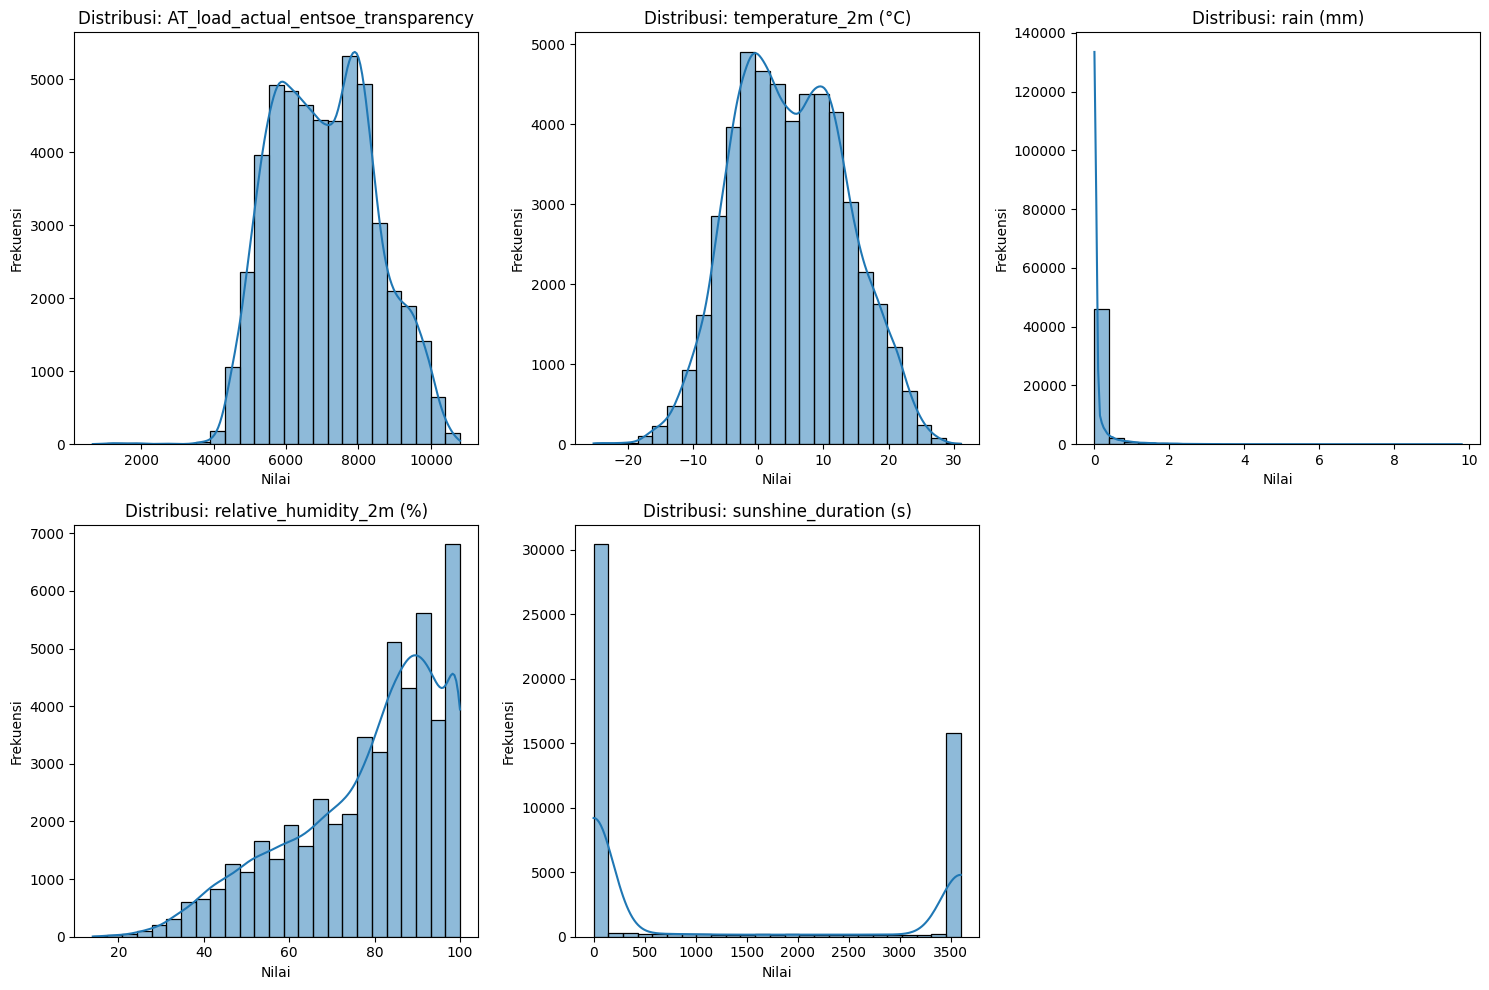

,AT_load_actual_entsoe_transparency,temperature_2m (°C),rain (mm),relative_humidity_2m (%),sunshine_duration (s)
count,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000
mean,7070.148631,4.873226,0.113232,78.249147,1268.193835
std,1400.263167,8.543645,0.416855,17.513486,1664.802739
min,664.000000,-25.300000,0.000000,14.000000,0.000000
25%,5941.000000,-1.600000,0.000000,67.000000,0.000000
50%,7032.000000,4.500000,0.000000,83.000000,0.000000
75%,8079.000000,11.100000,0.000000,92.000000,3600.000000
max,10803.000000,31.100000,9.800000,100.000000,3600.000000


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi distribusi dari raw data sebelum di-scaling
plt.figure(figsize=(15, 10))
for i, col in enumerate(cek.columns):
    plt.subplot(len(cek.columns) // 3 + 1, 3, i + 1)
    sns.histplot(cek[col], bins=25, kde=True)
    plt.title(f'Distribusi: {col}')
    plt.xlabel('Nilai')
    plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# Menampilkan statistik deskriptif dari data
display(cek.describe())

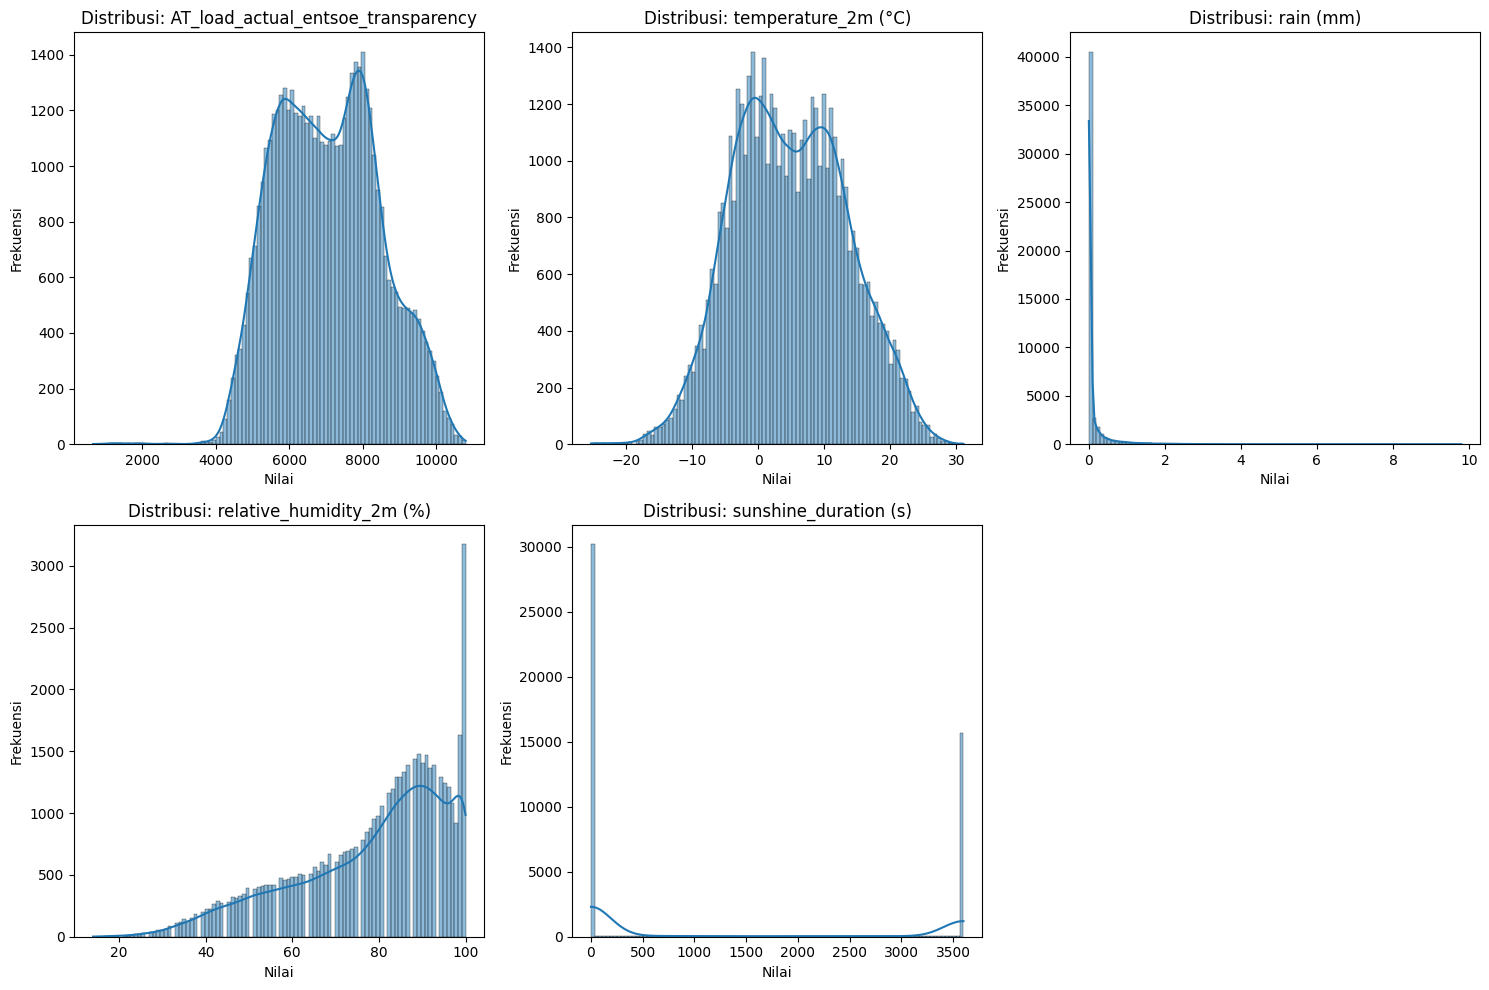

,AT_load_actual_entsoe_transparency,temperature_2m (°C),rain (mm),relative_humidity_2m (%),sunshine_duration (s)
count,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000
mean,7070.148631,4.873226,0.113232,78.249147,1268.193835
std,1400.263167,8.543645,0.416855,17.513486,1664.802739
min,664.000000,-25.300000,0.000000,14.000000,0.000000
25%,5941.000000,-1.600000,0.000000,67.000000,0.000000
50%,7032.000000,4.500000,0.000000,83.000000,0.000000
75%,8079.000000,11.100000,0.000000,92.000000,3600.000000
max,10803.000000,31.100000,9.800000,100.000000,3600.000000


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi distribusi dari raw data sebelum di-scaling
plt.figure(figsize=(15, 10))
for i, col in enumerate(cek.columns):
    plt.subplot(len(cek.columns) // 3 + 1, 3, i + 1)
    sns.histplot(cek[col], bins=100, kde=True)
    plt.title(f'Distribusi: {col}')
    plt.xlabel('Nilai')
    plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# Menampilkan statistik deskriptif dari data
display(cek.describe())

In [3]:
import os
import ast
import pickle
import numpy as np
import pandas as pd
import re

# Load scaler to reverse the normalization (inverse_transform)
with open('KAGGLE_RESULTS/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load the original unscaled reference DataFrame to know the proper dimensions
df = pd.read_csv("df_combined_AT.csv")
num_cols = df.drop(columns=['utc_timestamp']).shape[1]

# Re-define our experiment boundaries
horizons = [6, 12, 24, 48, 72]
feature_types = ['UNIVARIATE', 'MULTIVARIATE']
models_list = ['LSTM', 'BiLSTM', 'Attention']

# Helper to reverse transform array elements back to actual MW/Unit
def denormalize_array(arr, scaler, num_cols):
    """
    Invert Transform requires an array sized to the number of original features.
    Our target (Load) is the first column.
    """
    orig_shape = np.array(arr).shape
    flat_arr = np.array(arr).flatten()
    
    # Create the dummy zero array with shape (len, number_of_features)
    dummy = np.zeros((len(flat_arr), num_cols))
    dummy[:, 0] = flat_arr  # Target variable goes to index 0
    
    # Perform Inverse Transform and keep only the Target variable (first column)
    denorm = scaler.inverse_transform(dummy)[:, 0]
    return denorm.reshape(orig_shape)

def parse_array_string(s):
    # Safely parse string like "[0.1, 0.2]" or "[np.float64(0.1)]" into list
    if not isinstance(s, str):
        return s
    
    # Handle numpy types if they got serialized into the string (e.g. np.float64)
    s_clean = re.sub(r'np\.float\d+\(', '', s)
    s_clean = s_clean.replace(')', '')
    
    # Remove brackets
    s_clean = s_clean.strip('[]')
    # Replace multiple spaces with single space, commas with space
    s_clean = re.sub(r'[,]+', ' ', s_clean)
    s_clean = re.sub(r'\s+', ' ', s_clean).strip()
    
    # Convert to floats
    if not s_clean:
        return []
    return [float(x) for x in s_clean.split(' ')]

for ft in feature_types:
    for h in horizons:
        base_path = f"KAGGLE_RESULTS/{ft}/{h}h"
        results_dir = f"{base_path}/results"
        
        if not os.path.exists(results_dir):
            continue
            
        print(f"\n{'='*50}\nDenormalizing testing results for {ft} - {h}h\n{'='*50}")
            
        for model_name in models_list:
            csv_path = f"{results_dir}/{model_name}.csv"
            if not os.path.exists(csv_path):
                continue
                
            res_df = pd.read_csv(csv_path)
            
            # Use custom parser instead of ast.literal_eval to handle all string formats properly
            res_df['ACTUAL_VALUE_HORIZON'] = res_df['ACTUAL_VALUE_HORIZON'].apply(parse_array_string)
            res_df['PREDICTED_VALUE_HORIZON'] = res_df['PREDICTED_VALUE_HORIZON'].apply(parse_array_string)
            
            # Convert lists to NumPy arrays for vectorized denormalization
            all_actuals = np.array(res_df['ACTUAL_VALUE_HORIZON'].to_list())
            all_preds = np.array(res_df['PREDICTED_VALUE_HORIZON'].to_list())
            
            denorm_actuals = denormalize_array(all_actuals, scaler, num_cols)
            denorm_preds = denormalize_array(all_preds, scaler, num_cols)
            
            # Calculate Real unit MAPE per row (avoid division by zero with small epsilon)
            epsilon = 1e-10
            real_mapes = np.mean(np.abs((denorm_actuals - denorm_preds) / (denorm_actuals + epsilon)), axis=1) * 100
            
            # Store Real versions back to dataframe as lists
            res_df['DENORM_ACTUAL_VALUE_HORIZON'] = denorm_actuals.tolist()
            res_df['DENORM_PREDICTED_VALUE_HORIZON'] = denorm_preds.tolist()
            res_df['DENORM_MAPE_OF_THIS_DATA_POINT'] = real_mapes
            
            # Save the updated Dataframe to a new result CSV tracking file
            save_path = f"{results_dir}/{model_name}_denormalized.csv"
            res_df.to_csv(save_path, index=False)
            
            print(f" -> Saved denormalized values for {model_name} to: {save_path}")
            print(f"    Avg Global Real MAPE for this model: {np.mean(real_mapes):.4f}%")

print("\nAll model testing results have been successfully denormalized and saved!")


Denormalizing testing results for UNIVARIATE - 6h
 -> Saved denormalized values for LSTM to: KAGGLE_RESULTS/UNIVARIATE/6h/results/LSTM_denormalized.csv
    Avg Global Real MAPE for this model: 2.6464%
 -> Saved denormalized values for BiLSTM to: KAGGLE_RESULTS/UNIVARIATE/6h/results/BiLSTM_denormalized.csv
    Avg Global Real MAPE for this model: 2.5993%
 -> Saved denormalized values for Attention to: KAGGLE_RESULTS/UNIVARIATE/6h/results/Attention_denormalized.csv
    Avg Global Real MAPE for this model: 13.8385%

Denormalizing testing results for UNIVARIATE - 12h
 -> Saved denormalized values for LSTM to: KAGGLE_RESULTS/UNIVARIATE/12h/results/LSTM_denormalized.csv
    Avg Global Real MAPE for this model: 3.8937%
 -> Saved denormalized values for BiLSTM to: KAGGLE_RESULTS/UNIVARIATE/12h/results/BiLSTM_denormalized.csv
    Avg Global Real MAPE for this model: 3.6996%
 -> Saved denormalized values for Attention to: KAGGLE_RESULTS/UNIVARIATE/12h/results/Attention_denormalized.csv
    Avg 

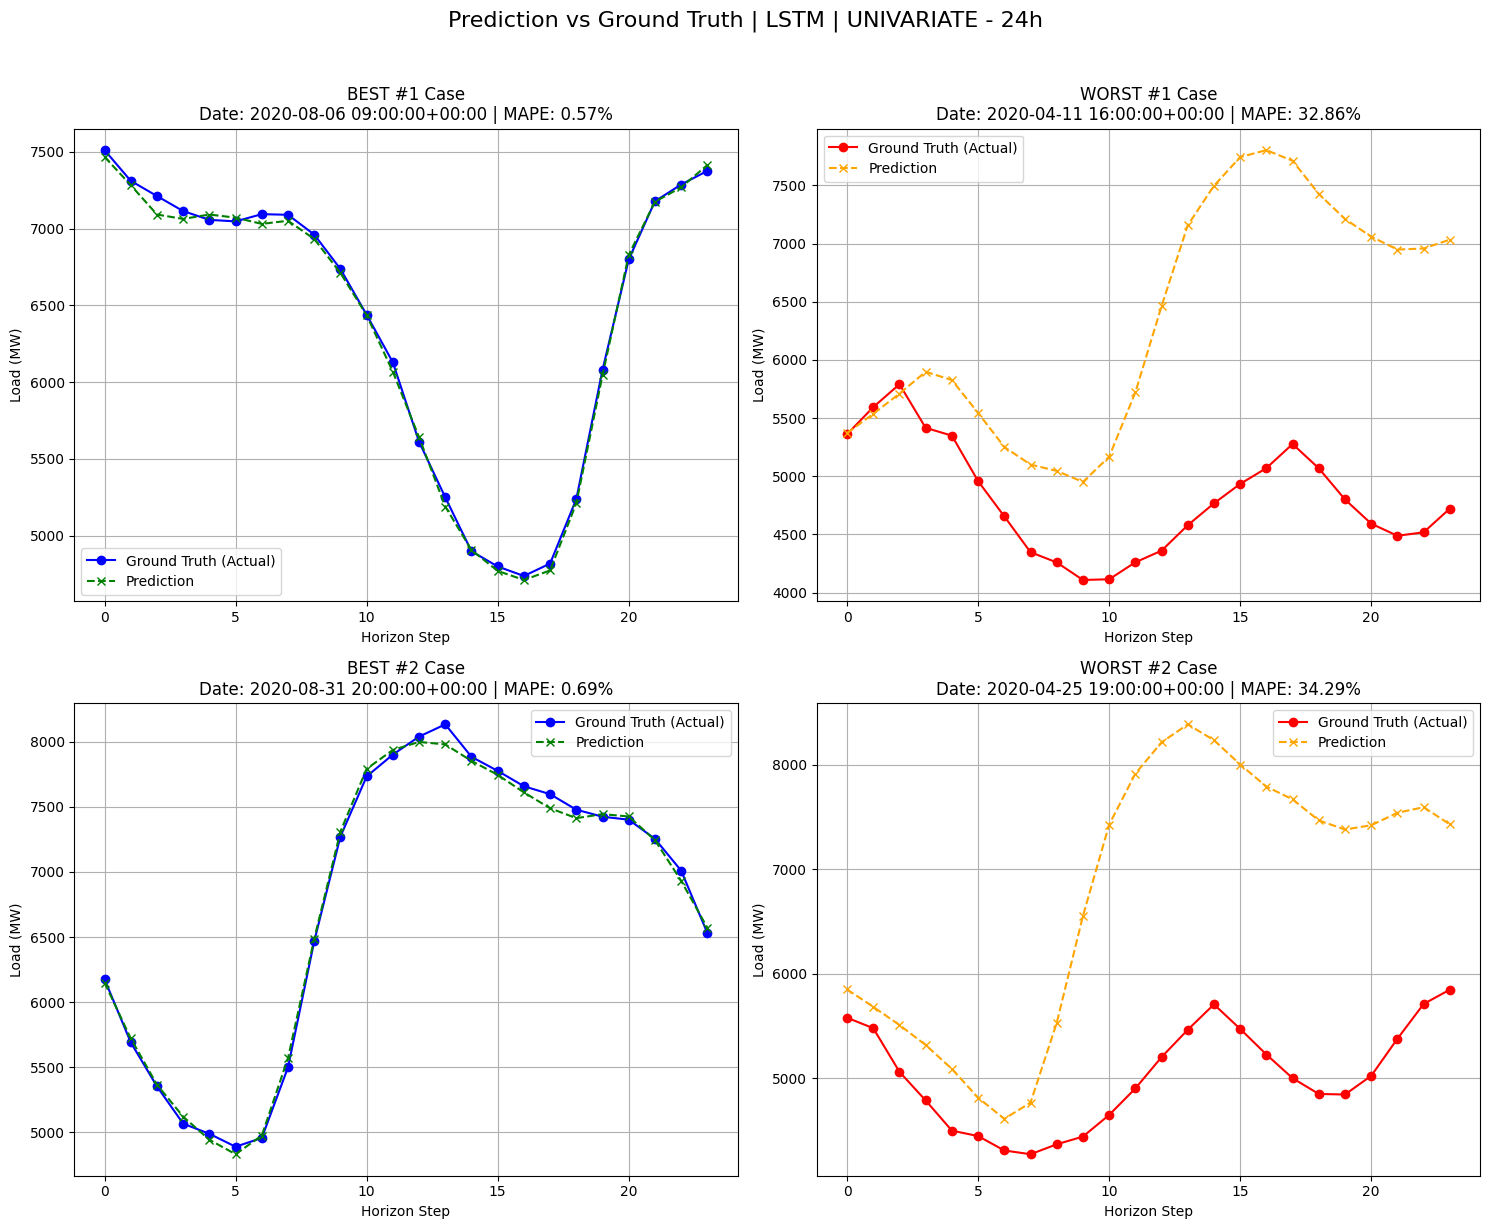

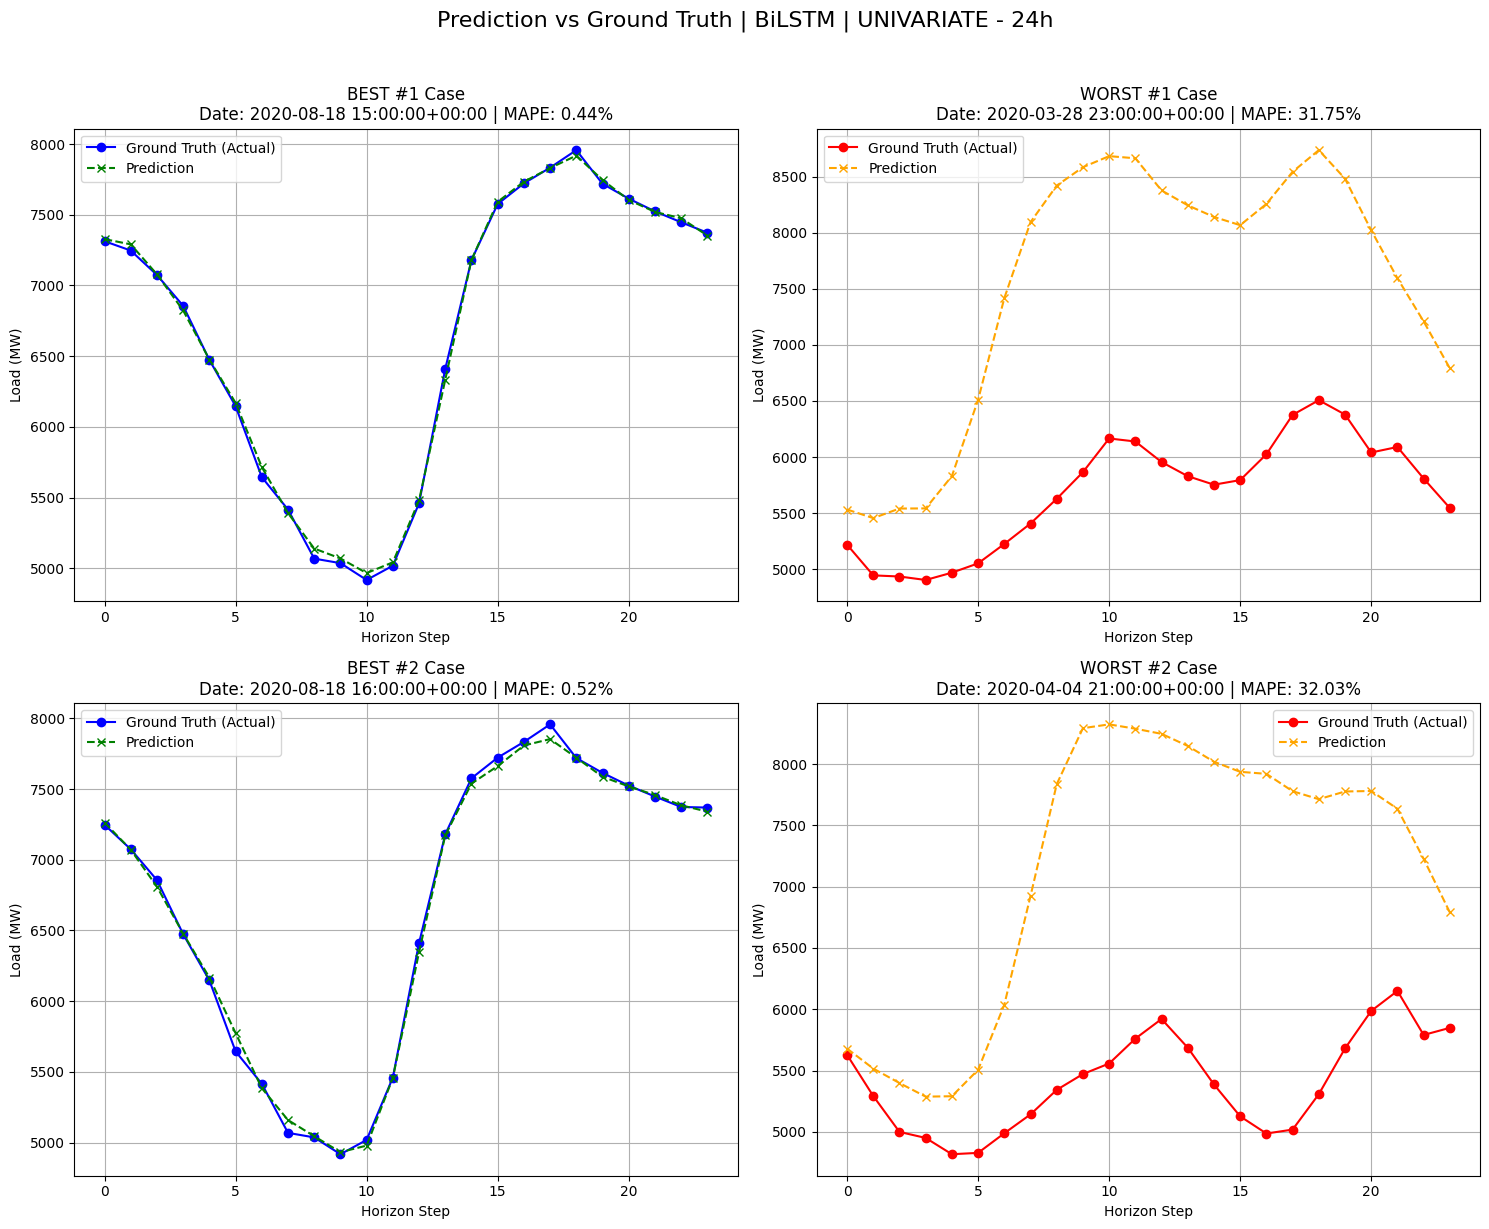

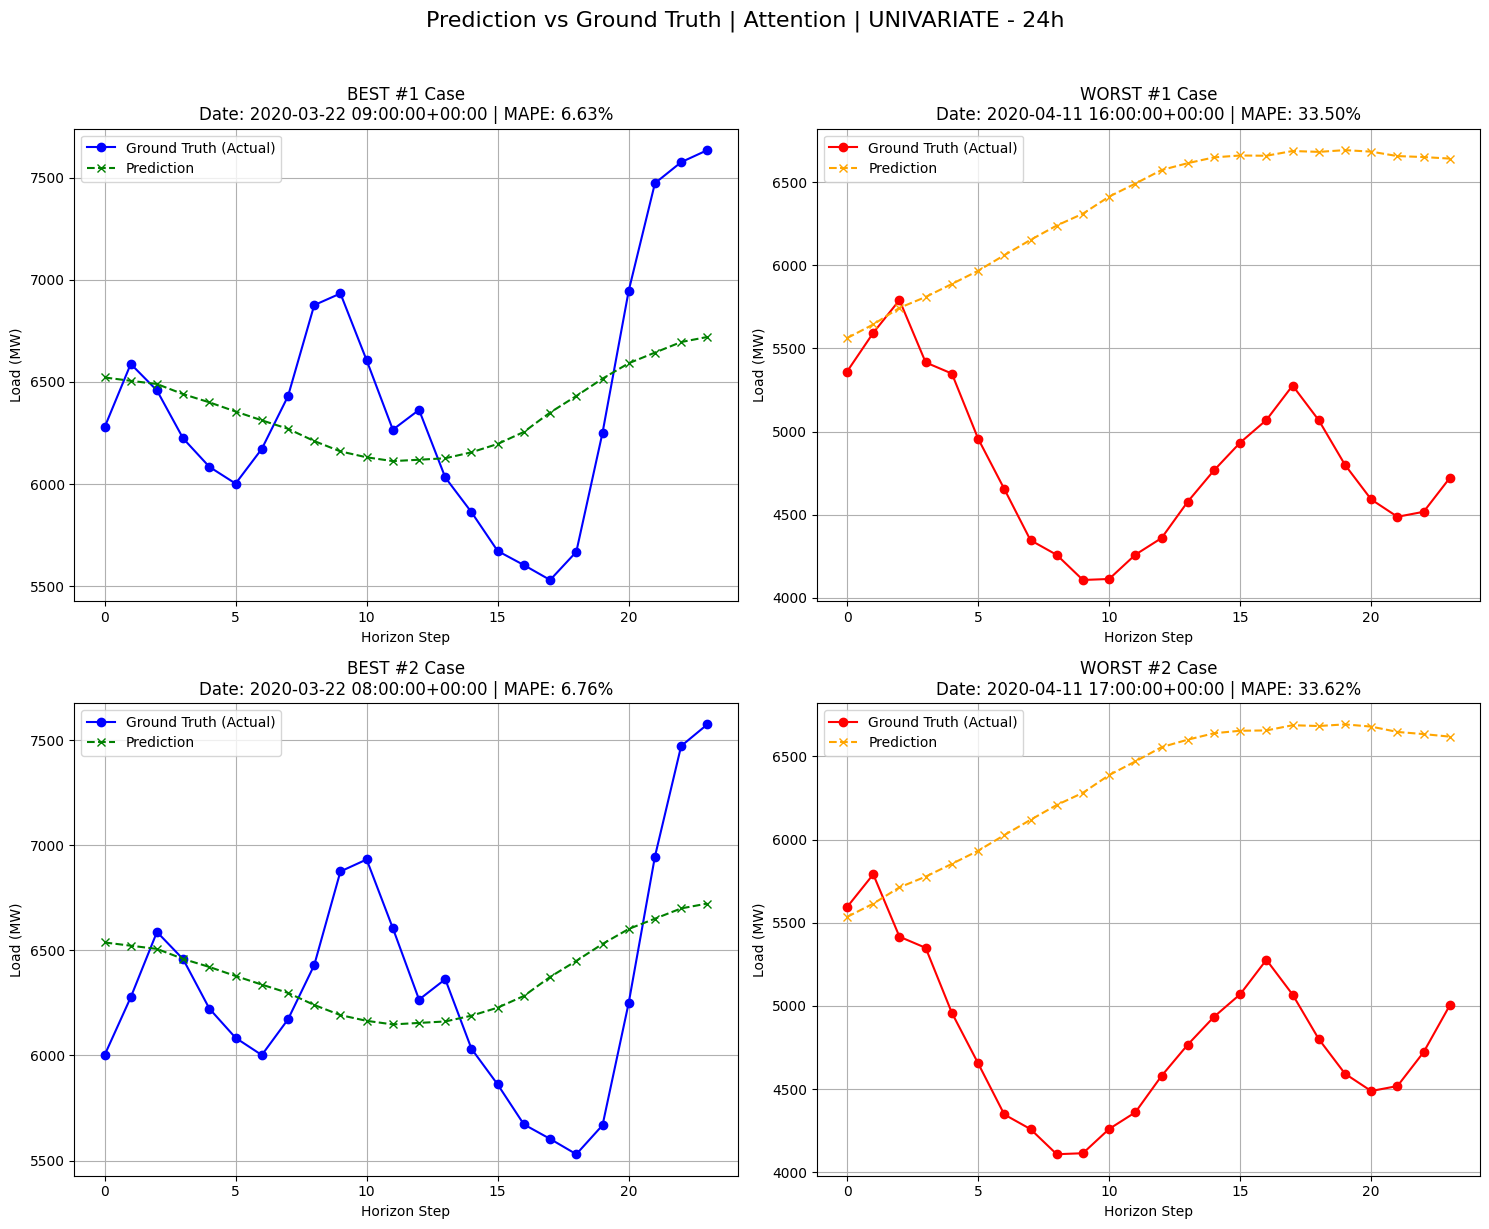

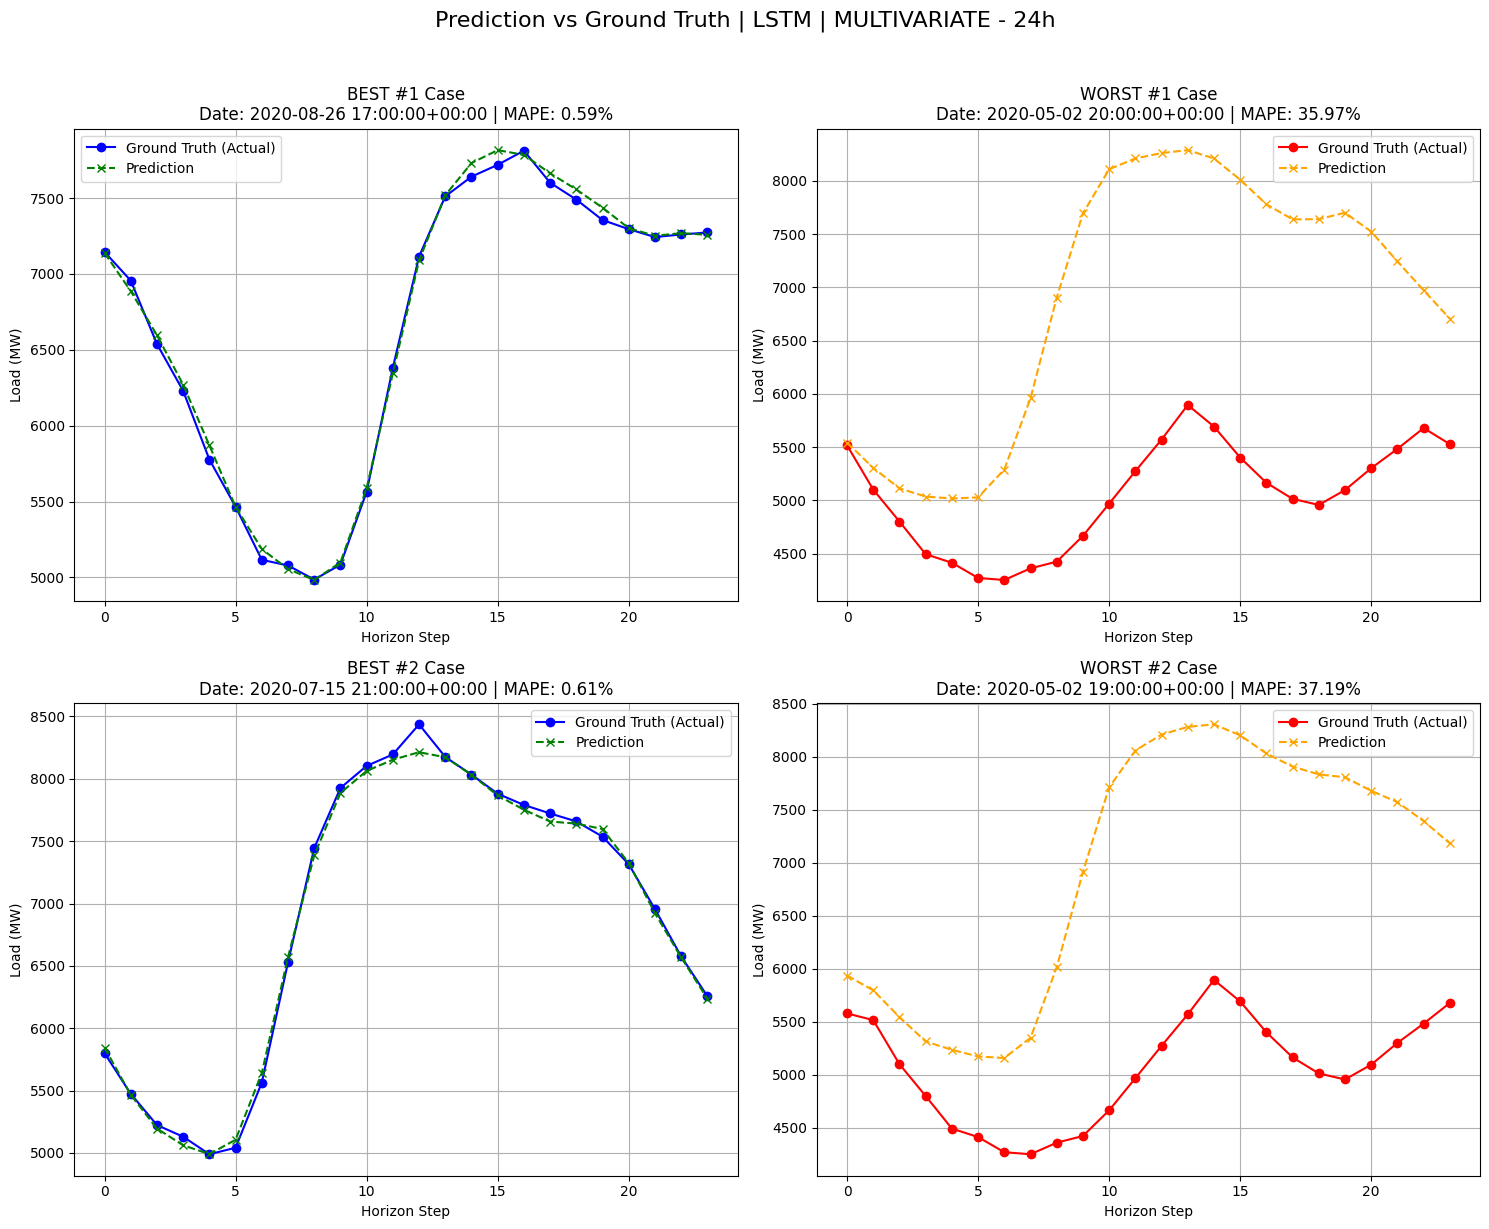

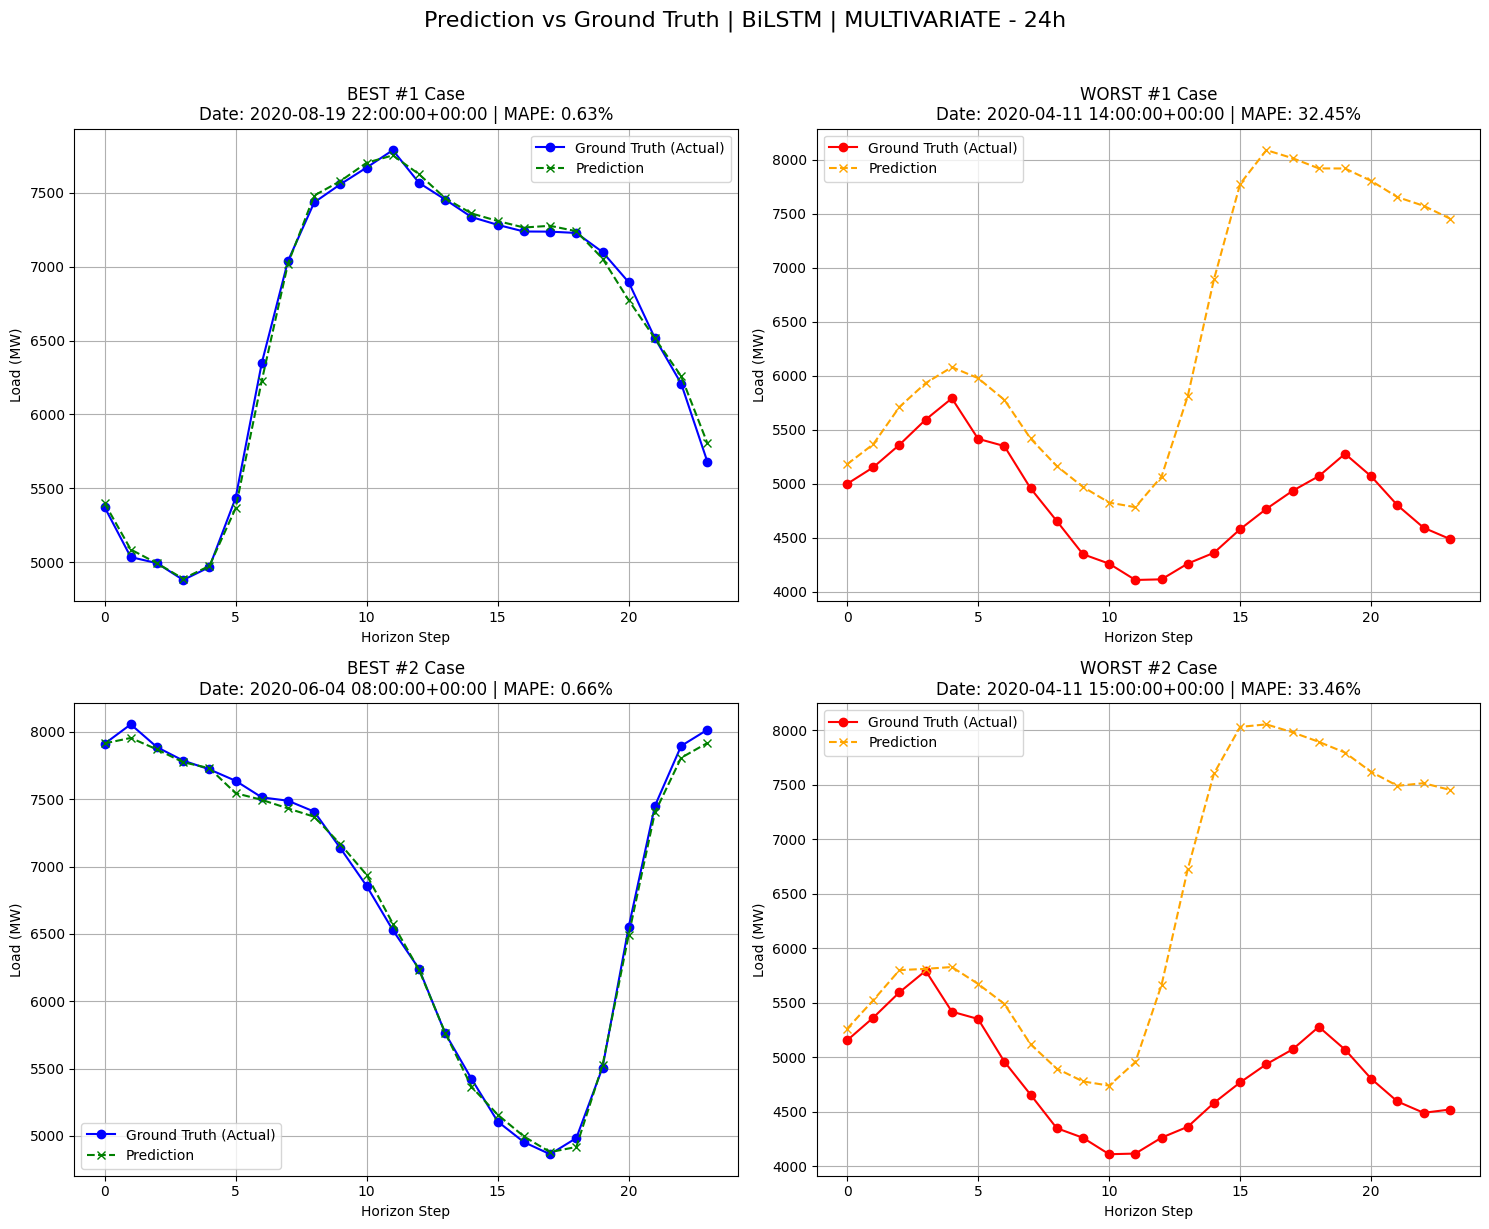

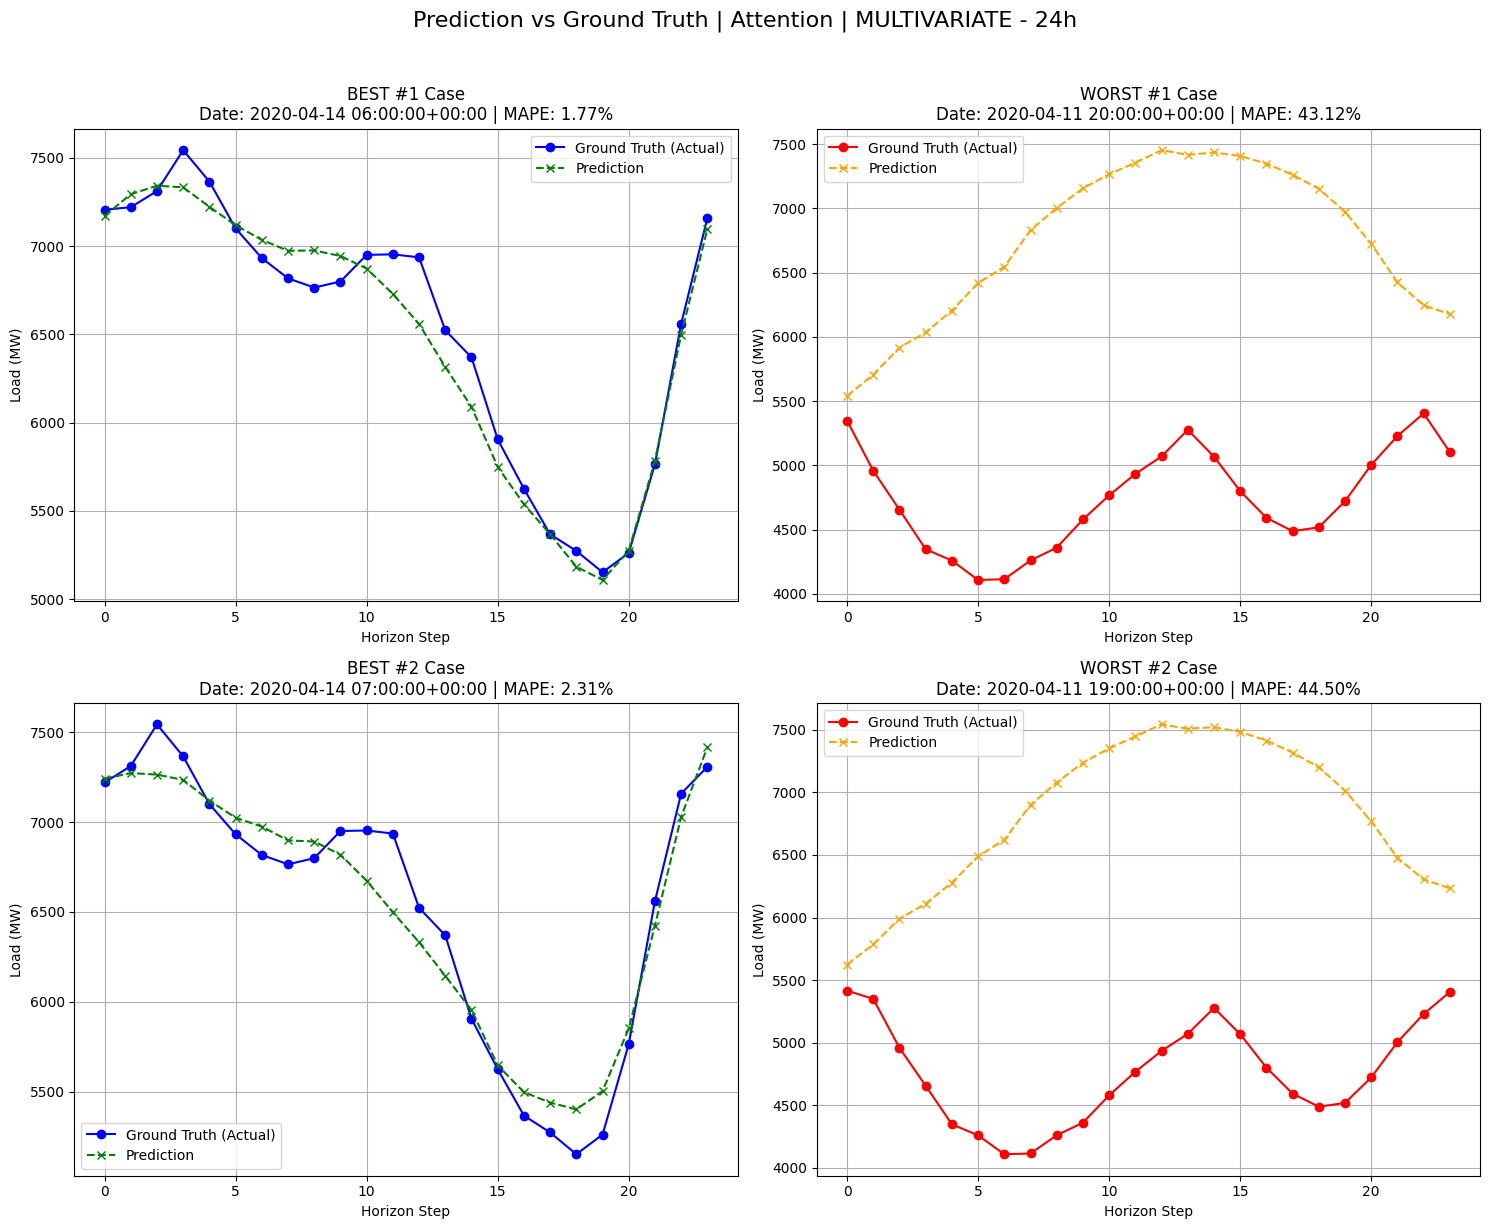

In [4]:
import matplotlib.pyplot as plt
import ast
import os
import pandas as pd
import re

def parse_array_string(s):
    # Safely parse string like "[0.1, 0.2]" or "[np.float64(0.1)]" into list
    if not isinstance(s, str):
        return s
    
    # Handle numpy types if they got serialized into the string (e.g. np.float64)
    s_clean = re.sub(r'np\.float\d+\(', '', s)
    s_clean = s_clean.replace(')', '')
    
    # Remove brackets
    s_clean = s_clean.strip('[]')
    # Replace multiple spaces with single space, commas with space
    s_clean = re.sub(r'[,]+', ' ', s_clean)
    s_clean = re.sub(r'\s+', ' ', s_clean).strip()
    
    # Convert to floats
    if not s_clean:
        return []
    return [float(x) for x in s_clean.split(' ')]

def plot_best_worst_cases(csv_path, model_name, ft, h, num_cases=2):
    if not os.path.exists(csv_path):
        return
    
    df_res = pd.read_csv(csv_path)
    
    # If the lists were saved as strings, parse them back
    if isinstance(df_res['DENORM_ACTUAL_VALUE_HORIZON'].iloc[0], str):
        df_res['DENORM_ACTUAL_VALUE_HORIZON'] = df_res['DENORM_ACTUAL_VALUE_HORIZON'].apply(parse_array_string)
        df_res['DENORM_PREDICTED_VALUE_HORIZON'] = df_res['DENORM_PREDICTED_VALUE_HORIZON'].apply(parse_array_string)
        
    # Sort dataframe by MAPE to find best (lowest) and worst (highest)
    df_sorted = df_res.sort_values(by='DENORM_MAPE_OF_THIS_DATA_POINT')
    
    # Drop NaNs just in case
    df_sorted = df_sorted.dropna(subset=['DENORM_MAPE_OF_THIS_DATA_POINT'])
    
    best_cases = df_sorted.head(num_cases)
    worst_cases = df_sorted.tail(num_cases)
    
    fig, axes = plt.subplots(num_cases, 2, figsize=(15, 6 * num_cases))
    fig.suptitle(f"Prediction vs Ground Truth | {model_name} | {ft} - {h}h", fontsize=16, y=1.02)
    
    # Single case handling if num_cases == 1
    if num_cases == 1:
        axes = [axes]
    
    for i in range(num_cases):
        # Best Case Plotting (Left Column)
        best_idx = best_cases.index[i]
        b_act = best_cases.loc[best_idx, 'DENORM_ACTUAL_VALUE_HORIZON']
        b_pred = best_cases.loc[best_idx, 'DENORM_PREDICTED_VALUE_HORIZON']
        b_mape = best_cases.loc[best_idx, 'DENORM_MAPE_OF_THIS_DATA_POINT']
        b_date = best_cases.loc[best_idx, 'DATE_OF_DATA_POINT']
        
        axes[i][0].plot(b_act, label='Ground Truth (Actual)', marker='o', color='blue')
        axes[i][0].plot(b_pred, label='Prediction', marker='x', color='green', linestyle='--')
        axes[i][0].set_title(f"BEST #{i+1} Case\nDate: {b_date} | MAPE: {b_mape:.2f}%")
        axes[i][0].set_xlabel("Horizon Step")
        axes[i][0].set_ylabel("Load (MW)")
        axes[i][0].legend()
        axes[i][0].grid(True)
        
        # Worst Case Plotting (Right Column)
        worst_idx = worst_cases.index[i]
        w_act = worst_cases.loc[worst_idx, 'DENORM_ACTUAL_VALUE_HORIZON']
        w_pred = worst_cases.loc[worst_idx, 'DENORM_PREDICTED_VALUE_HORIZON']
        w_mape = worst_cases.loc[worst_idx, 'DENORM_MAPE_OF_THIS_DATA_POINT']
        w_date = worst_cases.loc[worst_idx, 'DATE_OF_DATA_POINT']
        
        axes[i][1].plot(w_act, label='Ground Truth (Actual)', marker='o', color='red')
        axes[i][1].plot(w_pred, label='Prediction', marker='x', color='orange', linestyle='--')
        axes[i][1].set_title(f"WORST #{i+1} Case\nDate: {w_date} | MAPE: {w_mape:.2f}%")
        axes[i][1].set_xlabel("Horizon Step")
        axes[i][1].set_ylabel("Load (MW)")
        axes[i][1].legend()
        axes[i][1].grid(True)
        
    plt.tight_layout()
    plt.show()

# Example: Plot analysis for Target Horizon 24h only (to avoid rendering too many plots at once)
target_horizon = 24

for ft in feature_types:
    base_path = f"KAGGLE_RESULTS/{ft}/{target_horizon}h"
    results_dir = f"{base_path}/results"
    
    if os.path.exists(results_dir):
        for model_name in models_list:
            csv_path = f"{results_dir}/{model_name}_denormalized.csv"
            plot_best_worst_cases(csv_path, model_name, ft, target_horizon, num_cases=2)

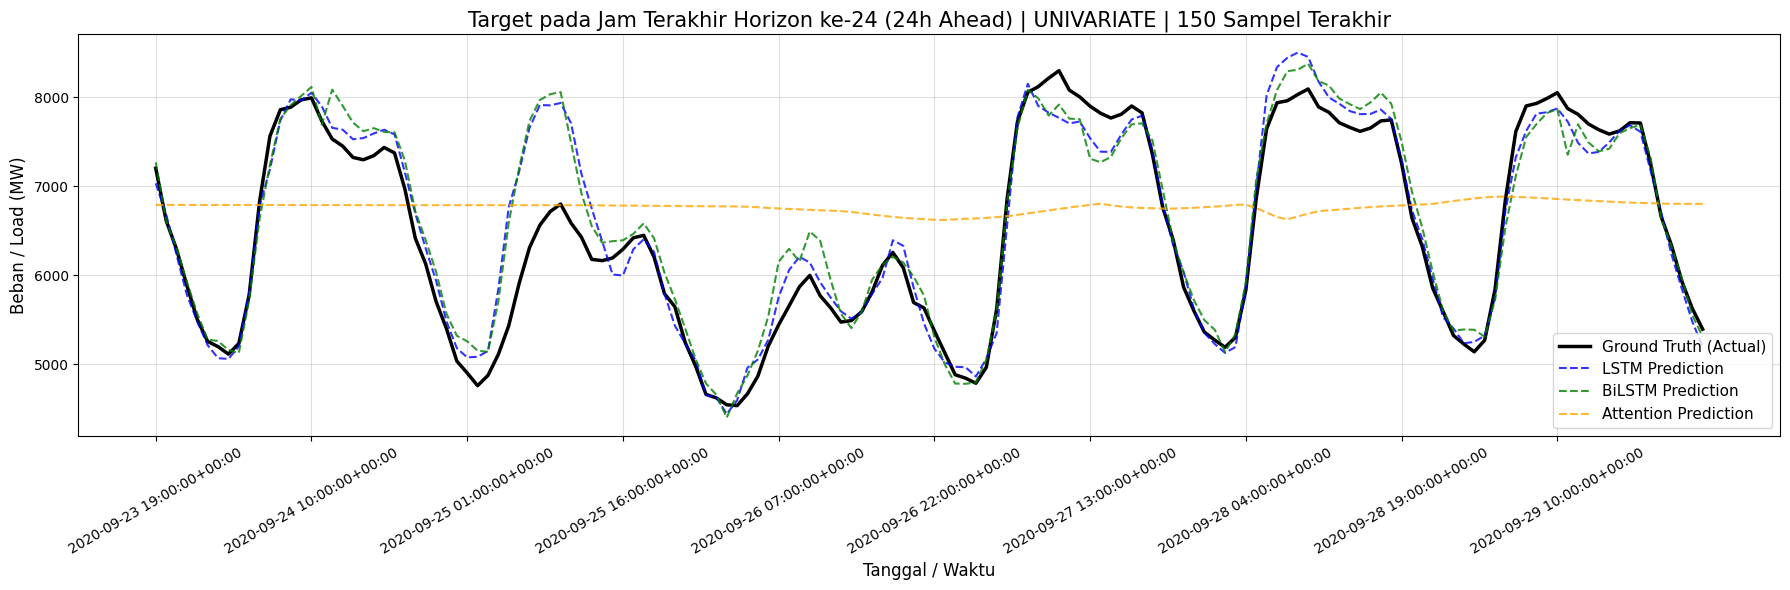

In [5]:
def plot_last_horizon_comparison(ft, h, plot_samples=200):
    base_path = f"KAGGLE_RESULTS/{ft}/{h}h"
    results_dir = f"{base_path}/results"
    
    models_list = ['LSTM', 'BiLSTM', 'Attention']
    predictions = {}
    actuals = None
    timestamps = None
    
    for model_name in models_list:
        csv_path = f"{results_dir}/{model_name}_denormalized.csv"
        if not os.path.exists(csv_path):
            print(f"File not found: {csv_path}")
            continue
            
        df_res = pd.read_csv(csv_path)
        
        # Parse strings to lists if needed
        if isinstance(df_res['DENORM_PREDICTED_VALUE_HORIZON'].iloc[0], str):
            df_res['DENORM_PREDICTED_VALUE_HORIZON'] = df_res['DENORM_PREDICTED_VALUE_HORIZON'].apply(parse_array_string)
            if actuals is None:
                df_res['DENORM_ACTUAL_VALUE_HORIZON'] = df_res['DENORM_ACTUAL_VALUE_HORIZON'].apply(parse_array_string)
        else:
            if actuals is None:
                df_res['DENORM_ACTUAL_VALUE_HORIZON'] = df_res['DENORM_ACTUAL_VALUE_HORIZON']
        
        # Extract the last time step of the horizon (index -1)
        preds_last_hour = [p[-1] for p in df_res['DENORM_PREDICTED_VALUE_HORIZON'] if len(p) > 0]
        predictions[model_name] = preds_last_hour
        
        if actuals is None:
            actuals = [a[-1] for a in df_res['DENORM_ACTUAL_VALUE_HORIZON'] if len(a) > 0]
            timestamps = df_res['DATE_OF_DATA_POINT'].tolist()

    if actuals is None:
        print("No valid data found to plot.")
        return

    # Use a subset of data so the plot is readable (e.g., the last N samples)
    actuals_subset = actuals[-plot_samples:]
    timestamps_subset = timestamps[-plot_samples:]
    
    plt.figure(figsize=(18, 6))
    plt.plot(timestamps_subset, actuals_subset, label='Ground Truth (Actual)', color='black', linewidth=2.5)
    
    colors = ['blue', 'green', 'orange', 'red', 'purple']
    for idx, (model_name, preds) in enumerate(predictions.items()):
        preds_subset = preds[-plot_samples:]
        plt.plot(timestamps_subset, preds_subset, label=f'{model_name} Prediction', 
                 color=colors[idx % len(colors)], linestyle='--', linewidth=1.5, alpha=0.8)
        
    plt.title(f"Target pada Jam Terakhir Horizon ke-{h} ({h}h Ahead) | {ft} | {plot_samples} Sampel Terakhir", fontsize=15)
    plt.xlabel("Tanggal / Waktu", fontsize=12)
    plt.ylabel("Beban / Load (MW)", fontsize=12)
    
    # Adjust ticks to prevent overlapping
    step = max(1, len(timestamps_subset) // 10)
    plt.xticks(ticks=range(0, len(timestamps_subset), step), 
               labels=[str(timestamps_subset[i]) for i in range(0, len(timestamps_subset), step)], 
               rotation=30)
    
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

# Contoh: Menjalankan Plotting untuk UNIVARIATE pada horizon 24h
# Mengambil 150 sampel timestamp terakhir dari Testing Data
plot_last_horizon_comparison(ft='UNIVARIATE', h=24, plot_samples=150)

In [19]:
import pandas as pd

cek = pd.read_csv('KAGGLE_RESULTS/UNIVARIATE/24h/results/LSTM_denormalized.csv')
cek

,DATE_OF_DATA_POINT,LAG_DATA,ACTUAL_VALUE_HORIZON,PREDICTED_VALUE_HORIZON,MAPE_OF_THIS_DATA_POINT,DENORM_ACTUAL_VALUE_HORIZON,DENORM_PREDICTED_VALUE_HORIZON,DENORM_MAPE_OF_THIS_DATA_POINT
0,2020-03-04 05:00:00+00:00,"[np.float64(0.7377453397770983), np.float64(0....","[0.751553407633889, 0.8273991517901174, 0.8511...","[0.7387534, 0.82828665, 0.8610059, 0.870525, 0...",1.970780,"[8284.000000000002, 9053.000000000002, 9294.00...","[8154.220722600001, 9061.99834435, 9393.738820...",1.813386
1,2020-03-04 06:00:00+00:00,"[np.float64(0.8272018936778776), np.float64(0....","[0.8273991517901174, 0.8511687543150213, 0.838...","[0.84051085, 0.878134, 0.8795539, 0.88079214, ...",2.557616,"[9053.000000000002, 9294.000000000002, 9165.00...","[9185.93950815, 9567.400626, 9581.7969921, 959...",2.358762
2,2020-03-04 07:00:00+00:00,"[np.float64(0.866258999901371), np.float64(0.8...","[0.8511687543150213, 0.8384456060755499, 0.840...","[0.85385084, 0.8600745, 0.8604439, 0.8596127, ...",2.218653,"[9294.000000000002, 9165.000000000002, 9184.0,...","[9321.19366676, 9384.2953555, 9388.04070210000...",2.035221
3,2020-03-04 08:00:00+00:00,"[np.float64(0.8776999704112831), np.float64(0....","[0.8384456060755499, 0.8403195581418286, 0.837...","[0.85160124, 0.859773, 0.8535024, 0.8414588, 0...",2.618499,"[9165.000000000002, 9184.0, 9158.0, 9068.0, 90...","[9298.38497236, 9381.238447, 9317.6608336, 919...",2.396417
4,2020-03-04 09:00:00+00:00,"[np.float64(0.8850971496202782), np.float64(0....","[0.8403195581418286, 0.8377552026827102, 0.828...","[0.8441621, 0.84304833, 0.8276787, 0.8135936, ...",3.451534,"[9184.0, 9158.0, 9068.0, 9009.0, 8843.00000000...","[9222.9595319, 9211.66701787, 9055.8343393, 89...",3.152650
...,...,...,...,...,...,...,...,...
5031,2020-09-29 20:00:00+00:00,"[np.float64(0.5657362659039353), np.float64(0....","[0.5578459414143406, 0.5120820593746918, 0.486...","[0.55423677, 0.51752985, 0.48613667, 0.4652437...",1.134849,"[6320.000000000001, 5856.000000000001, 5595.0,...","[6283.40661103, 5911.235149149999, 5592.939697...",1.017493
5032,2020-09-29 21:00:00+00:00,"[np.float64(0.5133642371042508), np.float64(0....","[0.5120820593746918, 0.4863398757273893, 0.459...","[0.5199729, 0.48285896, 0.4585619, 0.4462304, ...",2.026509,"[5856.000000000001, 5595.0, 5324.0, 5228.0, 51...","[5936.005233100001, 5559.70699544, 5313.359104...",1.835482
5033,2020-09-29 22:00:00+00:00,"[np.float64(0.4868330210079889), np.float64(0....","[0.4863398757273893, 0.4596114015188874, 0.450...","[0.47973263, 0.45215884, 0.4397258, 0.43219647...",3.366457,"[5595.0, 5324.0, 5228.0, 5141.0, 5270.0, 5839....","[5528.009135570001, 5248.43847876, 5122.379886...",3.048016
5034,2020-09-29 23:00:00+00:00,"[np.float64(0.46345793470756486), np.float64(0...","[0.4596114015188874, 0.4501430121313739, 0.441...","[0.46532366, 0.44785422, 0.43719625, 0.4445414...",3.695347,"[5324.0, 5228.0, 5141.0, 5270.0, 5839.0, 6848....","[5381.91658874, 5204.79393658, 5096.7327787500...",3.349355


In [20]:
cek = cek.sort_values(by='MAPE_OF_THIS_DATA_POINT').reset_index(drop=True)
cek

,DATE_OF_DATA_POINT,LAG_DATA,ACTUAL_VALUE_HORIZON,PREDICTED_VALUE_HORIZON,MAPE_OF_THIS_DATA_POINT,DENORM_ACTUAL_VALUE_HORIZON,DENORM_PREDICTED_VALUE_HORIZON,DENORM_MAPE_OF_THIS_DATA_POINT
0,2020-08-06 09:00:00+00:00,"[np.float64(0.7105237202879968), np.float64(0....","[0.6753131472531808, 0.6555873360291942, 0.645...","[0.6709532, 0.65284157, 0.63394094, 0.6311353,...",0.640058,"[7511.000000000001, 7311.000000000001, 7212.0,...","[7466.794494800001, 7283.16067823, 7091.527190...",0.571153
1,2020-08-31 20:00:00+00:00,"[np.float64(0.46947430713088073), np.float64(0...","[0.5436433573330703, 0.4958082651149028, 0.462...","[0.5410412, 0.49882936, 0.46375453, 0.439559, ...",0.770643,"[6176.000000000001, 5691.0, 5353.0, 5067.0, 49...","[6149.616726800001, 5721.6308810400005, 5366.0...",0.691489
2,2020-08-18 23:00:00+00:00,"[np.float64(0.42706381299930957), np.float64(0...","[0.43446099220830453, 0.4313048624124667, 0.41...","[0.4489361, 0.42888406, 0.41670936, 0.42780855...",0.804233,"[5069.0, 5037.0, 4918.0, 5019.0, 5460.0, 6411....","[5215.7631179, 5012.45548434, 4889.01620104, 5...",0.716032
3,2020-07-22 00:00:00+00:00,"[np.float64(0.4356445408817437), np.float64(0....","[0.43978696123878097, 0.42913502317782815, 0.4...","[0.44286475, 0.42778242, 0.43862978, 0.4929565...",0.823489,"[5123.000000000001, 5015.0, 5128.0, 5590.0, 65...","[5154.20570025, 5001.28595638, 5111.26733942, ...",0.745612
4,2020-08-18 01:00:00+00:00,"[np.float64(0.39066969129105433), np.float64(0...","[0.4049709044284446, 0.4145379228720781, 0.464...","[0.40772006, 0.4172858, 0.47019586, 0.5563492,...",0.853411,"[4770.0, 4867.0, 5372.0, 6274.000000000001, 70...","[4797.87368834, 4894.8607262000005, 5431.31582...",0.756371
...,...,...,...,...,...,...,...,...
5031,2020-05-23 22:00:00+00:00,"[np.float64(0.42489397376467103), np.float64(0...","[0.40181477463260673, 0.37094388006706774, 0.3...","[0.41280693, 0.4006992, 0.3951023, 0.3934369, ...",37.326095,"[4738.0, 4425.0, 4330.0, 4174.0, 4159.0, 4213....","[4849.449463270001, 4726.6891888, 4669.9422197...",32.395709
5032,2020-05-02 20:00:00+00:00,"[np.float64(0.46977019429924055), np.float64(0...","[0.4786468093500345, 0.43761712200414243, 0.40...","[0.47175667, 0.4436974, 0.42140976, 0.39852017...",37.369997,"[5517.0, 5101.0, 4801.0, 4494.0, 4414.0, 4271....","[5447.14087713, 5162.647938600001, 4936.673556...",32.508477
5033,2020-05-23 17:00:00+00:00,"[np.float64(0.5590294900877799), np.float64(0....","[0.518986093303087, 0.5100108491961732, 0.4847...","[0.5382755, 0.51857376, 0.5056119, 0.4898887, ...",37.572241,"[5926.0, 5835.000000000001, 5578.999999999999,...","[6121.5752944999995, 5921.819352640001, 5790.3...",32.596768
5034,2020-04-11 16:00:00+00:00,"[np.float64(0.5364434362363153), np.float64(0....","[0.46326067659532494, 0.4862412466712693, 0.50...","[0.46428597, 0.4805286, 0.4977153, 0.5162525, ...",38.302120,"[5361.0, 5593.999999999999, 5791.000000000001,...","[5371.39544983, 5536.079475400001, 5710.335426...",32.856433


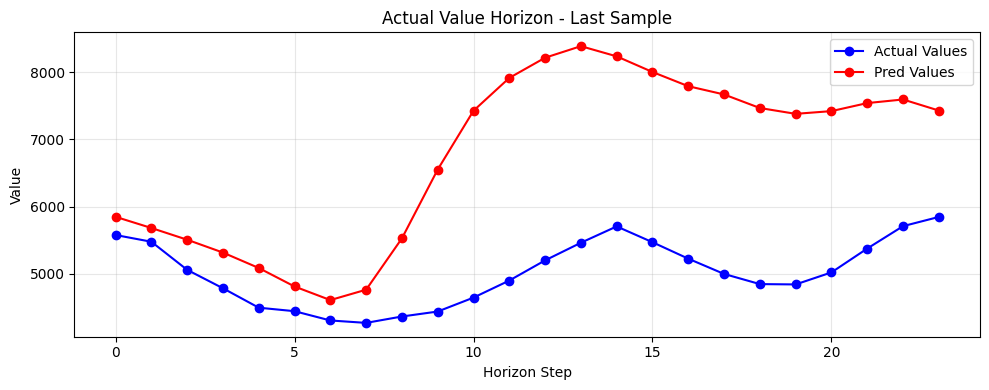

In [21]:
import matplotlib.pyplot as plt
import re

def parse_array_string(s):
    if not isinstance(s, str):
        return s
    s_clean = re.sub(r'np\.float\d+\(', '', s)
    s_clean = s_clean.replace(')', '')
    s_clean = s_clean.strip('[]')
    s_clean = re.sub(r'[,]+', ' ', s_clean)
    s_clean = re.sub(r'\s+', ' ', s_clean).strip()
    if not s_clean:
        return []
    return [float(x) for x in s_clean.split(' ')]

actual_value_str = cek['DENORM_ACTUAL_VALUE_HORIZON'].iloc[-1]
actual_value_list = parse_array_string(actual_value_str)

pred_val = cek['DENORM_PREDICTED_VALUE_HORIZON'].iloc[-1]

predicted_value_list = parse_array_string(pred_val)

plt.figure(figsize=(10, 4))
plt.plot(actual_value_list, marker='o', color='blue', label='Actual Values')

plt.plot(predicted_value_list, marker='o', color='red', label='Pred Values')
plt.title('Actual Value Horizon - Last Sample')
plt.xlabel('Horizon Step')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import re

def parse_array_string(s):
    if not isinstance(s, str):
        return s
    s_clean = re.sub(r'np\.float\d+\(', '', s)
    s_clean = s_clean.replace(')', '')
    s_clean = s_clean.strip('[]')
    s_clean = re.sub(r'[,]+', ' ', s_clean)
    s_clean = re.sub(r'\s+', ' ', s_clean).strip()
    if not s_clean:
        return []
    return [float(x) for x in s_clean.split(' ')]

feature_types = ['UNIVARIATE', 'MULTIVARIATE']
horizons = [6, 12, 24, 48, 72]
models_list = ['LSTM', 'BiLSTM', 'Attention']

for ft in feature_types:
    for h in horizons:
        # Create a figure for each feature type and horizon scenario
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        fig.suptitle(f'Worst Case (Max MAPE) Prediction vs Actual - {ft} | {h}h Horizon', fontsize=14, y=1.05)
        
        has_data = False
        
        for idx, model_name in enumerate(models_list):
            csv_path = f'KAGGLE_RESULTS/{ft}/{h}h/results/{model_name}_denormalized.csv'
            
            if not os.path.exists(csv_path):
                axes[idx].set_title(f'{model_name} (Data Not Found)')
                axes[idx].axis('off')
                continue
                
            has_data = True
            df = pd.read_csv(csv_path)
            
            # Use DENORM_MAPE_OF_THIS_DATA_POINT to sort and get the worst instance
            if 'DENORM_MAPE_OF_THIS_DATA_POINT' in df.columns:
                df = df.sort_values(by='DENORM_MAPE_OF_THIS_DATA_POINT').reset_index(drop=True)
            elif 'MAPE_OF_THIS_DATA_POINT' in df.columns:
                df = df.sort_values(by='MAPE_OF_THIS_DATA_POINT').reset_index(drop=True)
                
            # Grab the last one which is the worst MAPE
            actual_value_str = df['DENORM_ACTUAL_VALUE_HORIZON'].iloc[-1]
            actual_value_list = parse_array_string(actual_value_str)
            
            pred_val = df['DENORM_PREDICTED_VALUE_HORIZON'].iloc[-1]
            predicted_value_list = parse_array_string(pred_val)
            
            mape_val = df['DENORM_MAPE_OF_THIS_DATA_POINT'].iloc[-1] if 'DENORM_MAPE_OF_THIS_DATA_POINT' in df.columns else None
            
            axes[idx].plot(actual_value_list, marker='o', color='blue', label='Actual Values')
            axes[idx].plot(predicted_value_list, marker='o', color='red', label='Pred Values')
            
            title = f'{model_name}'
            if mape_val is not None:
                title += f' (MAPE: {mape_val:.2f}%)'
            axes[idx].set_title(title)
            
            axes[idx].set_xlabel('Horizon Step')
            axes[idx].set_ylabel('Value')
            axes[idx].grid(True, alpha=0.3)
            axes[idx].legend()
            
        plt.tight_layout()
        if has_data:
            plt.show()
        else:
            plt.close(fig)

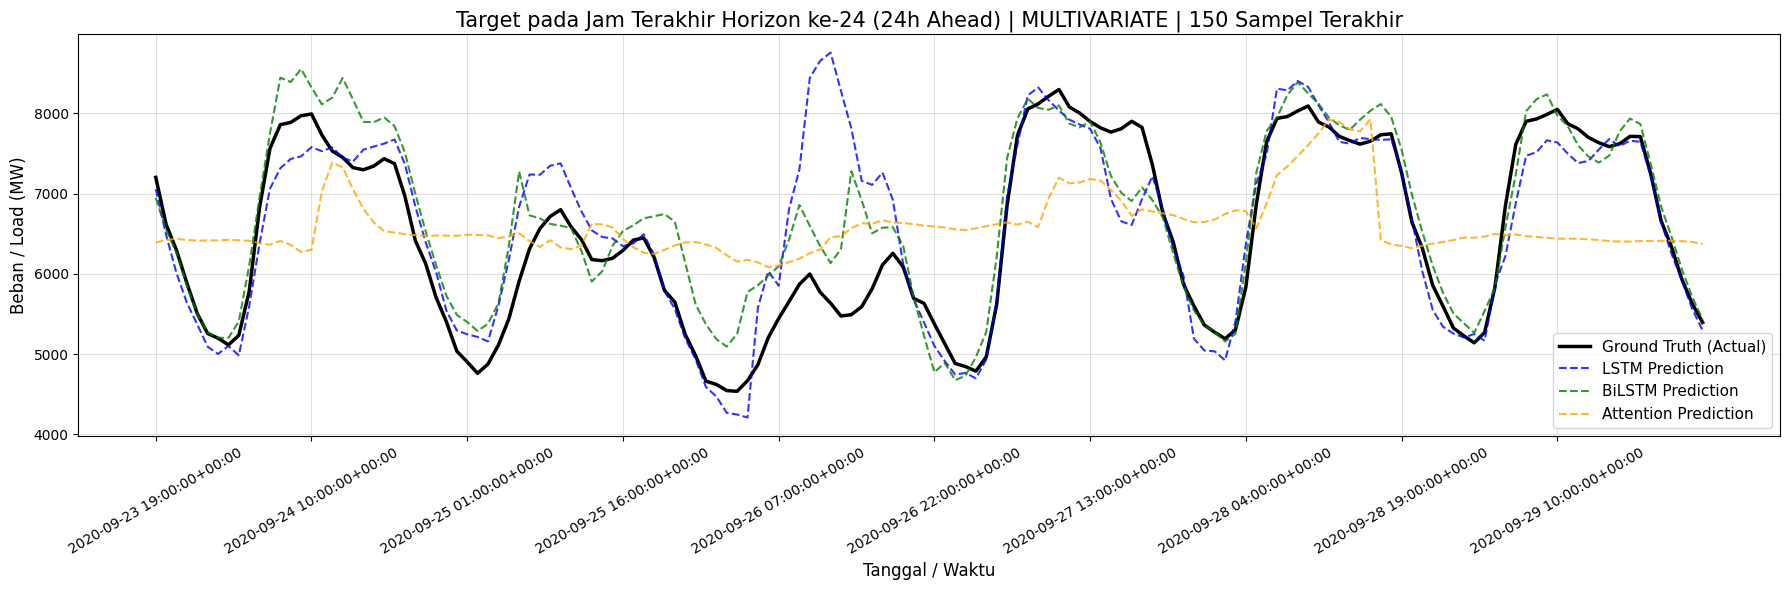

In [6]:
plot_last_horizon_comparison(ft='MULTIVARIATE', h=24, plot_samples=150)

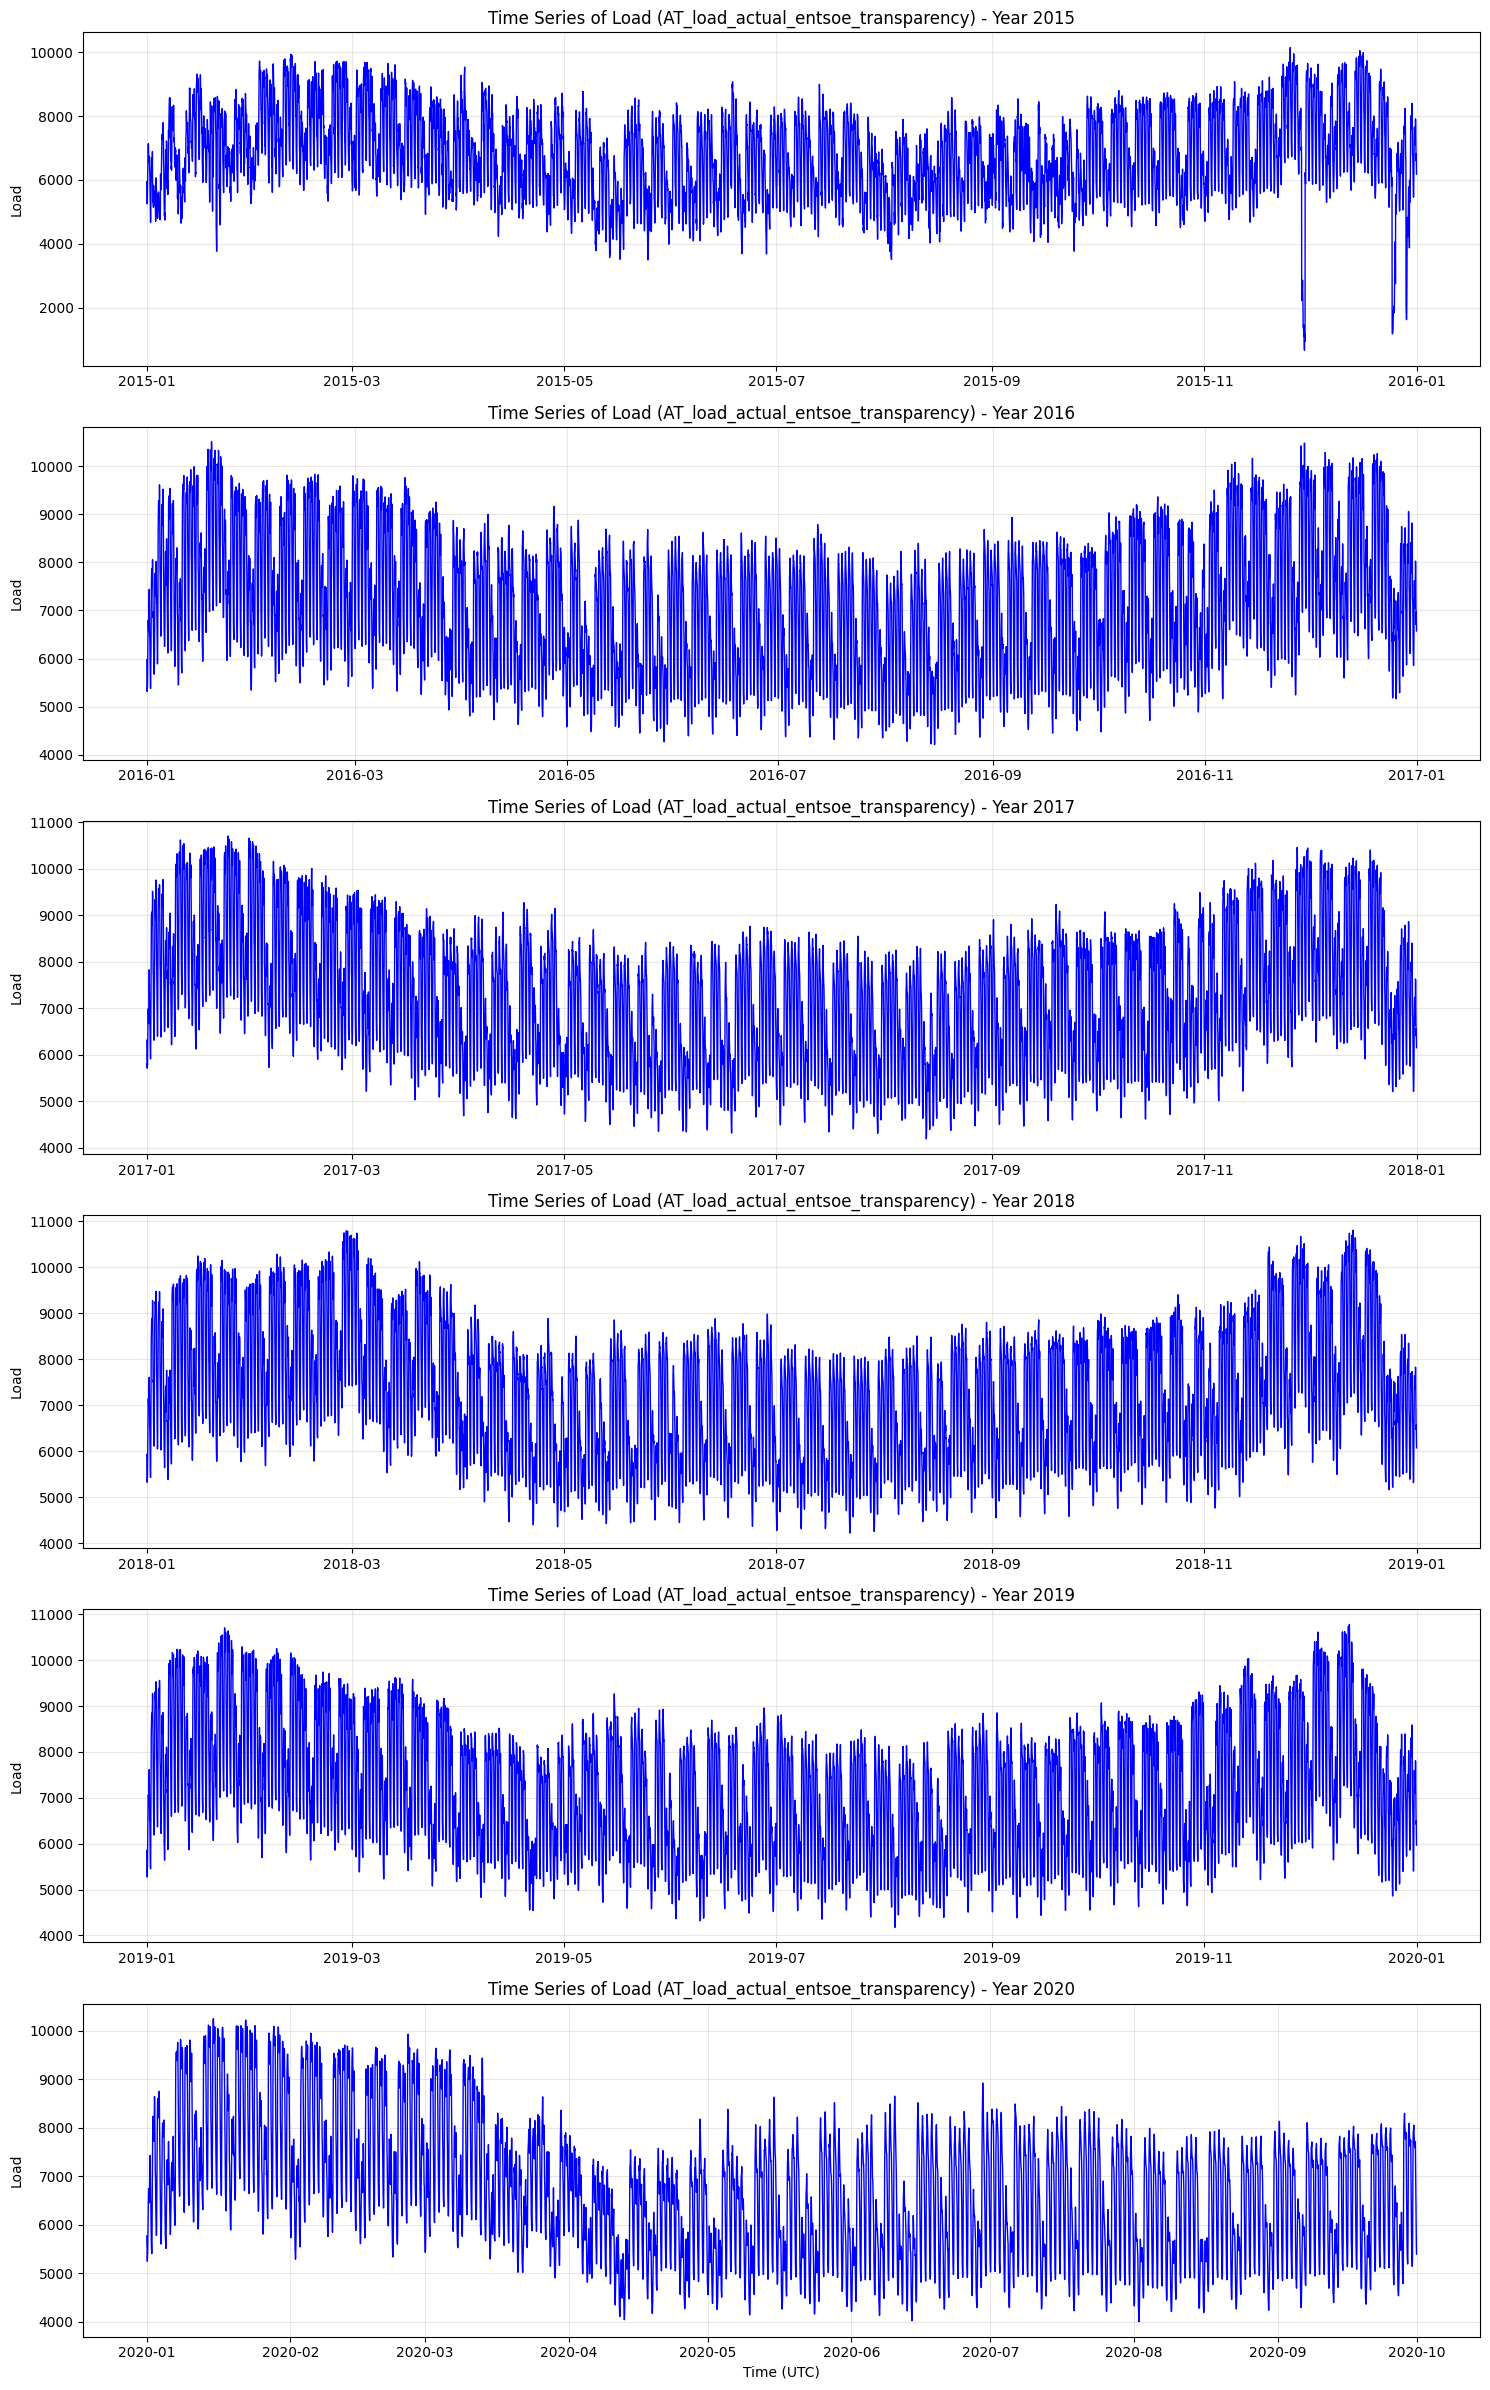

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert timestamp to datetime if not already
datetime_series = pd.to_datetime(data['utc_timestamp'])
years = datetime_series.dt.year.unique()

fig, axes = plt.subplots(len(years), 1, figsize=(15, 4 * len(years)))

# Ensure axes is iterable even if there's only 1 year
if len(years) == 1:
    axes = [axes]

for i, year in enumerate(years):
    mask = datetime_series.dt.year == year
    axes[i].plot(datetime_series[mask], data['AT_load_actual_entsoe_transparency'][mask], color='blue', linewidth=1)
    axes[i].set_title(f'Time Series of Load (AT_load_actual_entsoe_transparency) - Year {year}')
    axes[i].set_ylabel('Load')
    axes[i].grid(True, alpha=0.3)

plt.xlabel('Time (UTC)')
plt.tight_layout()
plt.show()

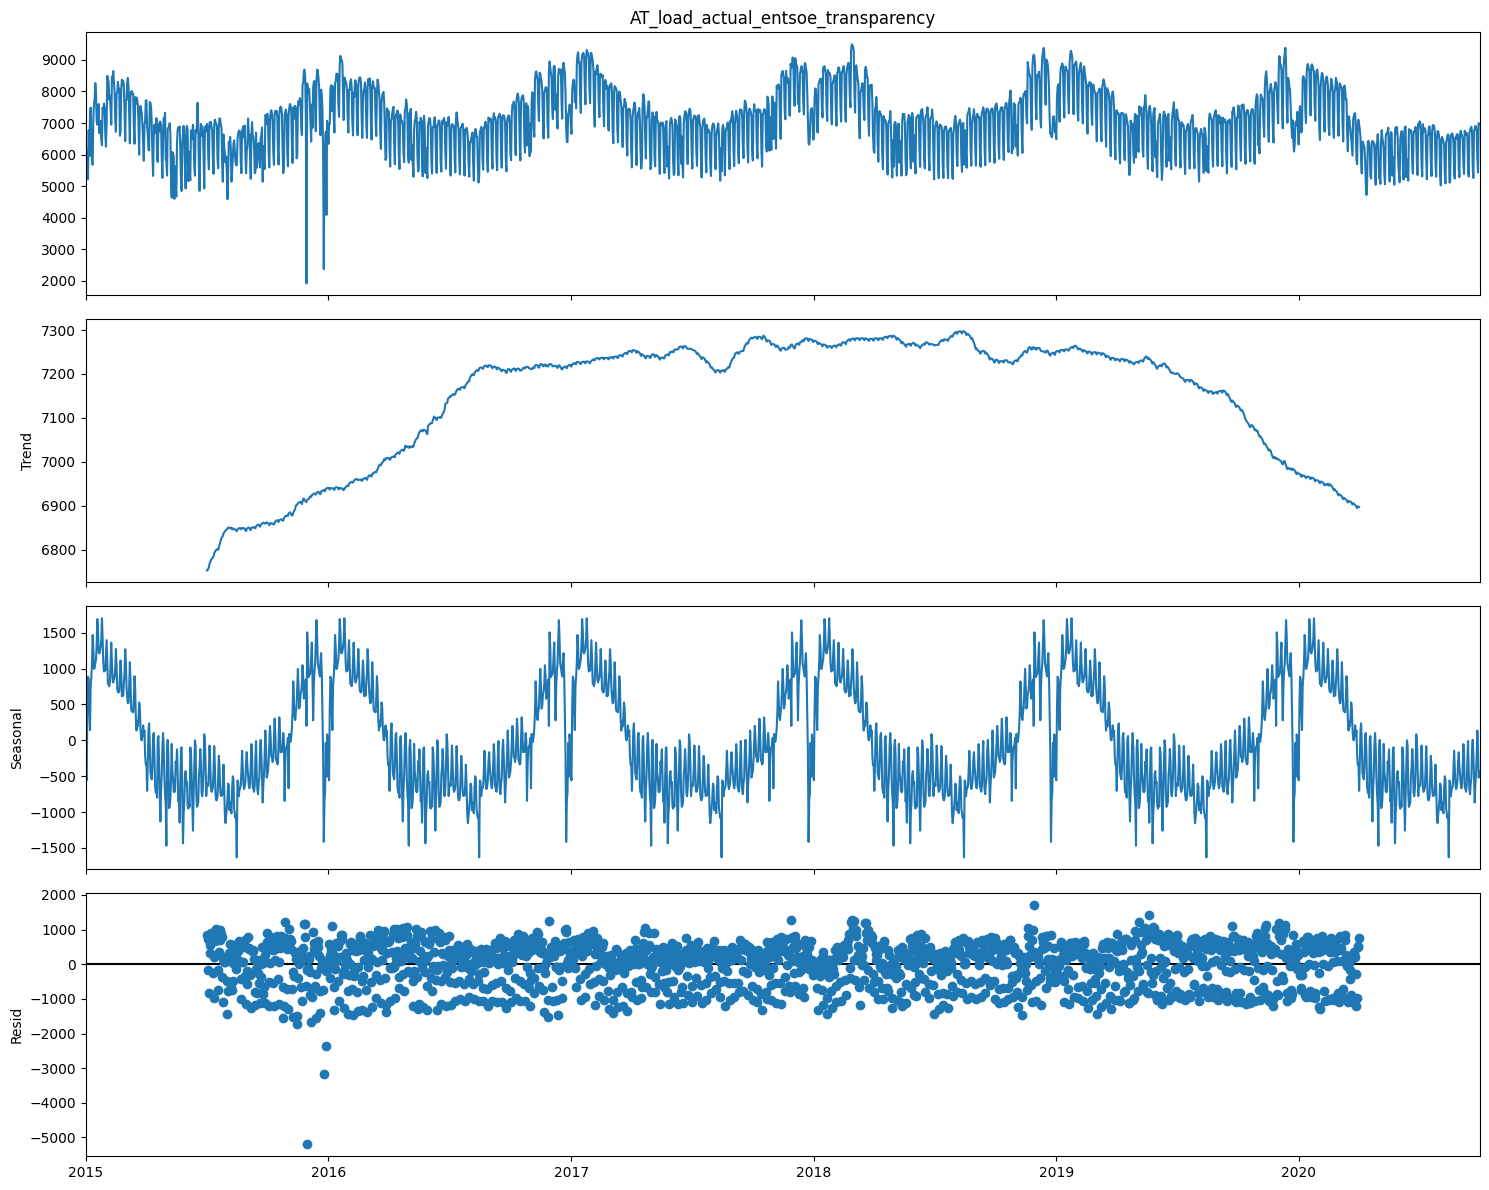

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import pandas as pd

# Create a copy and set the timestamp as index
df_ts = data[['utc_timestamp', 'AT_load_actual_entsoe_transparency']].copy()
df_ts['utc_timestamp'] = pd.to_datetime(df_ts['utc_timestamp'])
df_ts.set_index('utc_timestamp', inplace=True)

# Resample to daily frequency (average load per day) to make the overall trend and seasonality clearer
df_daily = df_ts.resample('D').mean().dropna()

# Perform time series decomposition
# Using period=365 for daily data to see the yearly seasonal pattern
decomposition = seasonal_decompose(df_daily['AT_load_actual_entsoe_transparency'], model='additive', period=365)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(15, 12)
plt.tight_layout()
plt.show()